# CV（Computer Vision）: 计算机视觉
- 定义：计算机视觉是让计算机理解和分析视觉世界（图片、视频）的技术领域，核心目标是从图像或视频数据中获取有用信息并作出判断。
- 它涉及 图像获取、处理、分析，最终输出结构化信息或预测结果。
## 1. 常见场景
1. 图像分类（Image Classification）

- 功能：判断整张图片属于哪个类别
- 应用：手写数字识别、猫狗分类、医学影像诊断
- 代表模型：ResNet、DenseNet、EfficientNet、Vision Transformer（ViT）、ConvNeXt

2. 目标检测（Object Detection）
- 功能：在图片中找到并定位物体（输出边界框 + 类别）
- 应用：人脸检测、交通监控、无人驾驶
- 代表模型：YOLO 系列（YOLOv5、YOLOX、YOLOv8）、Faster R-CNN、RetinaNet、DETR（基于Transformer）

3. 语义分割（Semantic Segmentation）
- 功能：为图片中每个像素分类（像素级别分割）
- 应用：医学影像分割、自动驾驶路面检测
- 代表模型：U-Net、DeepLabV3+、SegFormer


4. 实例分割（Instance Segmentation）
- 功能：在像素级别标注每个单独物体
- 应用：自动驾驶中车/人识别、工业缺陷检测
- 代表模型：Mask R-CNN、CondInst、SOLOv2


5. 图像生成（Image Generation）
- 功能：基于训练或提示词生成新图像
- 应用：艺术创作、虚拟环境生成
- 代表模型：GAN（StyleGAN、CycleGAN）、Diffusion Models（Stable Diffusion、DALL·E）、ControlNet（可控生成）

6. 人脸识别与活体检测
- 功能：提取人脸特征并验证身份
- 应用：门禁、支付验证
- 代表模型：FaceNet、ArcFace、InsightFace

7. 姿态估计（Pose Estimation）
- 功能：定位人体关键点（关节位置）
- 应用：运动分析、手势识别
- 代表模型：OpenPose、MediaPipe Pose、HRNet

8. 图像文本理解（Vision + Language）
- 功能：将CV与NLP结合，让模型理解图片并用自然语言描述
- 应用：图像字幕生成（Image Captioning）、VQA（Visual Question Answering）
- 代表模型：CLIP（OpenAI）、BLIP / BLIP-2、LLaVA（LLM+Vision）、Flamingo

## 2. CV 中的数据集（常用）
| 任务类型 |	代表数据集 |
| --- | --- |
| 图像分类 |	ImageNet, CIFAR-10/100 |
| 目标检测 |	COCO, Pascal VOC |
| 语义分割 |	Cityscapes, ADE20K |
| 实例分割 |	COCO, LVIS |
| 面部识别 |	LFW, VGGFace2 |
| 姿态估计 |	MPII, COCO Keypoints |
| 图像生成 |	CelebA, LAION-5B |

In [2]:
!pip install Pillow

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/45/89/da2f7971a317f83d807fdd4065c0af40208e59e692cc43d315a71a0e96d1/pillow-12.3.0-cp312-cp312-win_amd64.whl (7.2 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from transformers import pipeline
from PIL import Image

# 创建图像分类pipeline； 下载: google/vit-base-patch16-224
vision_classifier = pipeline("image-classification")

# 加载图像
img01 = Image.open("img/pic1.jpg")
img02 = Image.open("img/pic2.jpg")

# 进行分类预测
predictions1 = vision_classifier(img01)
print(f"图片1 {predictions1}")

predictions2 = vision_classifier(img02)
print(f"图片2 {predictions2}")

D:\Program Files\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] No model was supplied, defaulted to google/vit-base-patch16-224 and revision 3f49326.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 11297.18it/s]


图片1 [{'label': 'Labrador retriever', 'score': 0.958014726638794}, {'label': 'golden retriever', 'score': 0.01660529524087906}, {'label': 'kuvasz', 'score': 0.0025836960412561893}, {'label': 'Chesapeake Bay retriever', 'score': 0.0021155616268515587}, {'label': 'tennis ball', 'score': 0.0015674862079322338}]
图片2 [{'label': 'Persian cat', 'score': 0.7110278010368347}, {'label': 'Angora, Angora rabbit', 'score': 0.07287649065256119}, {'label': 'lynx, catamount', 'score': 0.04107653722167015}, {'label': 'Egyptian cat', 'score': 0.02645809017121792}, {'label': 'tabby, tabby cat', 'score': 0.015502410009503365}]


In [14]:
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor
from huggingface_hub import hf_hub_download
import json

model_name = "facebook/detr-resnet-50"
revision = "no_timm"

# 1. 下载并读取配置文件
config_path = hf_hub_download(repo_id=model_name, filename="config.json", revision=revision)
with open(config_path, "r") as f:
    config_dict = json.load(f)

# 2. 核心修复：将 dilation 从 None 改为 False
config_dict["dilation"] = False

# 3. 用修正后的字典创建配置对象
config = DetrConfig.from_dict(config_dict)

# 4. 正常加载处理器和模型（显式传入修改后的 config）
processor = DetrImageProcessor.from_pretrained(model_name, revision=revision)
model = DetrForObjectDetection.from_pretrained(
    model_name, 
    revision=revision, 
    config=config   # 使用修补后的配置
)

# 5. 之后的使用完全不变
from PIL import Image
import requests

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)

# 后续解码（可选）
results = processor.post_process_object_detection(outputs, target_sizes=[image.size[::-1]])[0]
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    if score > 0.9:
        print(f"{model.config.id2label[label.item()]}: {score.item():.3f}  box: {box.tolist()}")

Loading weights: 100%|██████████| 530/530 [00:00<00:00, 52263.63it/s]


remote: 0.998  box: [40.16353225708008, 70.8105239868164, 175.54779052734375, 117.98514556884766]
remote: 0.996  box: [333.241943359375, 72.54872131347656, 368.3296203613281, 187.66297912597656]
couch: 0.995  box: [-0.022449493408203125, 1.149587631225586, 639.72705078125, 473.7620849609375]
cat: 0.999  box: [13.245964050292969, 52.050621032714844, 314.01727294921875, 470.9324035644531]
cat: 0.999  box: [345.4010009765625, 23.85601043701172, 640.3716430664062, 368.7200012207031]


Loading weights: 100%|██████████| 530/530 [00:00<00:00, 54575.79it/s]


检测结果：
remote: 0.998  框坐标: [40.16353225708008, 70.8105239868164, 175.54779052734375, 117.98514556884766]
remote: 0.996  框坐标: [333.241943359375, 72.54872131347656, 368.3296203613281, 187.66297912597656]
couch: 0.995  框坐标: [-0.022449493408203125, 1.149587631225586, 639.72705078125, 473.7620849609375]
cat: 0.999  框坐标: [13.245964050292969, 52.050621032714844, 314.01727294921875, 470.9324035644531]
cat: 0.999  框坐标: [345.4010009765625, 23.85601043701172, 640.3716430664062, 368.7200012207031]


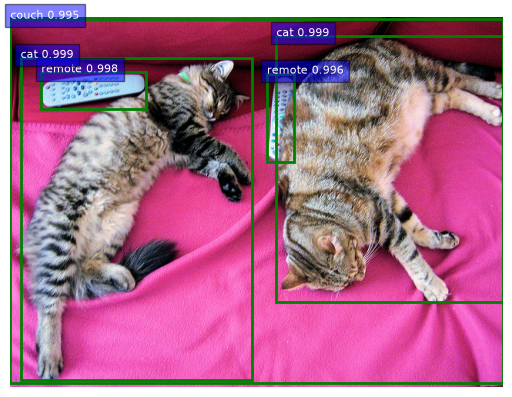

In [18]:
from transformers import pipeline
from PIL import Image
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 读取图片（你可以改成自己的文件路径）
# url = "http://images.cocodataset.org/val2017/000000039769.jpg"
# image = Image.open(requests.get(url, stream=True).raw)
image = Image.open("img/object.jpg")

# # 创建 pipeline
# object_detector = pipeline(
#     "object-detection", 
#     model="facebook/detr-resnet-50", 
#     revision="no_timm"   # 不用 timm 库
# )

# # 推理
# results = object_detector(image, threshold=0.9)  # 阈值控制置信度


model_name = "facebook/detr-resnet-50"
revision = "no_timm"

# 1. 下载并读取配置文件
config_path = hf_hub_download(repo_id=model_name, filename="config.json", revision=revision)
with open(config_path, "r") as f:
    config_dict = json.load(f)

# 2. 核心修复：将 dilation 从 None 改为 False
config_dict["dilation"] = False

# 3. 用修正后的字典创建配置对象
config = DetrConfig.from_dict(config_dict)

# 4. 正常加载处理器和模型（显式传入修改后的 config）
processor = DetrImageProcessor.from_pretrained(model_name, revision=revision)
model = DetrForObjectDetection.from_pretrained(
    model_name, 
    revision=revision, 
    config=config   # 使用修补后的配置
)

# 5. 之后的使用完全不变
from PIL import Image
import requests

# url = "http://images.cocodataset.org/val2017/000000039769.jpg"
# image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)

# 后续解码（可选）
# ---------- 解码检测结果 ----------
# results 是一个列表，每个元素对应一张图片，我们取第一张
detections = processor.post_process_object_detection(outputs, target_sizes=[image.size[::-1]])[0]

# 获取类别名称映射（从模型配置中读取）
id2label = model.config.id2label

# 设置置信度阈值（你可以调整）
threshold = 0.9

print("检测结果：")
for score, label_id, box in zip(detections["scores"], detections["labels"], detections["boxes"]):
    if score > threshold:
        label = id2label[label_id.item()]
        box_coords = box.tolist()  # [xmin, ymin, xmax, ymax]
        print(f"{label}: {score.item():.3f}  框坐标: {box_coords}")

# ---------- 可视化 ----------
fig, ax = plt.subplots(1)
ax.imshow(image)

for score, label_id, box in zip(detections["scores"], detections["labels"], detections["boxes"]):
    if score > threshold:
        label = id2label[label_id.item()]
        xmin, ymin, xmax, ymax = box.tolist()
        w, h = xmax - xmin, ymax - ymin
        rect = patches.Rectangle((xmin, ymin), w, h, linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin, f"{label} {score:.3f}", 
                fontsize=8, color='white', bbox=dict(facecolor='blue', alpha=0.5))

plt.axis("off")
plt.show()
